# Day 4 - Machine Learning

# Placement Prediction & Recommendation Platform

This notebook develops machine learning models for predicting student placement outcomes based on academic performance, technical skills, internships, projects, and aptitude scores.

The notebook covers the complete machine learning pipeline, including data preprocessing, feature engineering, model training, evaluation, hyperparameter tuning, and model comparison.

The trained models developed in this notebook will be used for:

- Placement Prediction
- Salary Package Prediction
- Student Recommendation System
- Career Guidance Module
- Gradio Dashboard Integration

## Objectives

The primary objectives of this notebook are:

- Prepare the dataset for machine learning
- Perform data preprocessing and feature engineering
- Create a machine learning-ready dataset
- Analyze feature distributions and relationships
- Split the dataset into training and testing sets
- Train multiple machine learning classification models
- Optimize model performance using hyperparameter tuning
- Evaluate models using standard classification metrics
- Analyze feature importance and model interpretability
- Compare model performance to identify the best predictive model
- Save the best-performing model for deployment in the Placement Intelligence Platform

## Import Libraries

In [426]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import mysql.connector

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import warnings
warnings.filterwarnings("ignore")

## Connect to MySQL

In [427]:
import os

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.getenv("MYSQL_PASSWORD"),
    database="placement_platform"
)

cursor = conn.cursor()

print("✅ Connected Successfully!")

Connected Successfully!


## Load Required Tables

In [428]:
students = pd.read_sql("SELECT * FROM Students", conn)

branches = pd.read_sql("SELECT * FROM Branches", conn)

roles = pd.read_sql("SELECT * FROM Roles", conn)

skills = pd.read_sql("SELECT * FROM Skills", conn)

student_skills = pd.read_sql("SELECT * FROM StudentSkills", conn)

In [429]:
print("Students:", students.shape)
print("Branches:", branches.shape)
print("Roles:", roles.shape)
print("Skills:", skills.shape)
print("Student Skills:", student_skills.shape)

Students: (750, 15)
Branches: (8, 4)
Roles: (36, 3)
Skills: (92, 4)
Student Skills: (5245, 2)


## Section 1 - Creating the Machine Learning Dataset

## 1. Calculate Skill Count

In [430]:
skill_count = (
    student_skills
    .groupby("StudentID")
    .size()
    .reset_index(name="SkillCount")
)

skill_count.head()

,StudentID,SkillCount
0,3001,6
1,3002,9
2,3003,8
3,3004,5
4,3005,8


## 2. Merge Branch Names

In [431]:
ml_dataset = (
    students
    .merge(
        branches[["BranchID", "BranchName"]],
        on="BranchID",
        how="left"
    )
)

## 3. Merge Preferred Role

In [432]:
ml_dataset = (
    ml_dataset
    .merge(
        roles[["RoleID", "RoleName"]],
        left_on="PreferredRoleID",
        right_on="RoleID",
        how="left"
    )
)

## 4. Merge Skill Count

In [433]:
ml_dataset = (
    ml_dataset
    .merge(
        skill_count,
        on="StudentID",
        how="left"
    )
)

## 5. Remove Duplicate Columns

In [434]:
ml_dataset.drop(
    columns=["RoleID"],
    inplace=True
)

## 6. Verify the Dataset

In [435]:
print("Shape:", ml_dataset.shape)

ml_dataset.head()

Shape: (750, 18)


,StudentID,Name,Gender,Email,Phone,BranchID,CGPA,CodingScore,DSASolved,Projects,Internships,CommunicationScore,AptitudeScore,PreferredRoleID,PlacementStatus,BranchName,RoleName,SkillCount
0,3001,Aditya Das,Male,aditya.das.22bt001@nitdgp.ac.in,9091031647,8,7.84,81,420,1,1,65,100,28,Not Placed,Biotechnology,Research Associate,6
1,3002,Vikram Pillai,Male,vikram.pillai.22bt002@nitdgp.ac.in,9755943945,8,9.58,93,779,3,1,53,67,29,Placed,Biotechnology,Research Engineer,9
2,3003,Amit Gupta,Male,amit.gupta.22bt003@nitdgp.ac.in,9666125292,8,9.22,93,647,4,1,93,90,29,Placed,Biotechnology,Research Engineer,8
3,3004,Sayan Yadav,Male,sayan.yadav.22bt004@nitdgp.ac.in,9339721639,8,7.98,82,388,4,2,81,94,28,Not Placed,Biotechnology,Research Associate,5
4,3005,Sayan Mishra,Male,sayan.mishra.22bt005@nitdgp.ac.in,9273424259,8,9.35,69,169,2,0,52,62,28,Not Placed,Biotechnology,Research Associate,8


## Section 2 - Data Inspection

## 1. Dataset Information

In [436]:
ml_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           750 non-null    int64  
 1   Name                750 non-null    str    
 2   Gender              750 non-null    str    
 3   Email               750 non-null    str    
 4   Phone               750 non-null    str    
 5   BranchID            750 non-null    int64  
 6   CGPA                750 non-null    float64
 7   CodingScore         750 non-null    int64  
 8   DSASolved           750 non-null    int64  
 9   Projects            750 non-null    int64  
 10  Internships         750 non-null    int64  
 11  CommunicationScore  750 non-null    int64  
 12  AptitudeScore       750 non-null    int64  
 13  PreferredRoleID     750 non-null    int64  
 14  PlacementStatus     750 non-null    str    
 15  BranchName          750 non-null    str    
 16  RoleName           

## 2. Missing Values

In [437]:
ml_dataset.isnull().sum()

StudentID             0
Name                  0
Gender                0
Email                 0
Phone                 0
BranchID              0
CGPA                  0
CodingScore           0
DSASolved             0
Projects              0
Internships           0
CommunicationScore    0
AptitudeScore         0
PreferredRoleID       0
PlacementStatus       0
BranchName            0
RoleName              0
SkillCount            0
dtype: int64

## 3. Duplicate Records

In [438]:
print("Duplicate Records:", ml_dataset.duplicated().sum())

Duplicate Records: 0


## 4. Statistical Summary

In [439]:
ml_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,750.0,3375.500000,216.650640,3001.00,3188.25,3375.50,3562.7500,3750.00
BranchID,750.0,3.366667,2.053414,1.00,1.00,3.00,5.0000,8.00
CGPA,750.0,8.280973,0.805923,6.53,7.65,8.32,8.9575,9.88
CodingScore,750.0,71.860000,15.576089,40.00,60.00,71.00,85.0000,100.00
DSASolved,750.0,265.078667,210.831580,20.00,80.00,205.00,409.2500,799.00
Projects,750.0,3.281333,1.316243,1.00,2.00,3.00,4.0000,6.00
Internships,750.0,0.958667,0.859812,0.00,0.00,1.00,2.0000,3.00
CommunicationScore,750.0,74.424000,14.326964,50.00,62.00,74.00,86.0000,100.00
AptitudeScore,750.0,71.905333,16.150009,45.00,58.00,72.00,86.0000,100.00
PreferredRoleID,750.0,18.190667,9.367140,1.00,10.00,20.00,26.0000,35.00


In [440]:
ml_dataset["SkillCount"].describe()

count    750.000000
mean       6.993333
std        1.425950
min        4.000000
25%        6.000000
50%        7.000000
75%        8.000000
max       12.000000
Name: SkillCount, dtype: float64

## 5. Checking Class Balance

In [441]:
ml_dataset["PlacementStatus"].value_counts()

PlacementStatus
Not Placed    396
Placed        354
Name: count, dtype: int64

In [442]:
ml_dataset["PlacementStatus"]

0      Not Placed
1          Placed
2          Placed
3      Not Placed
4      Not Placed
          ...    
745    Not Placed
746        Placed
747    Not Placed
748    Not Placed
749        Placed
Name: PlacementStatus, Length: 750, dtype: str

## Visualization - Count Plot

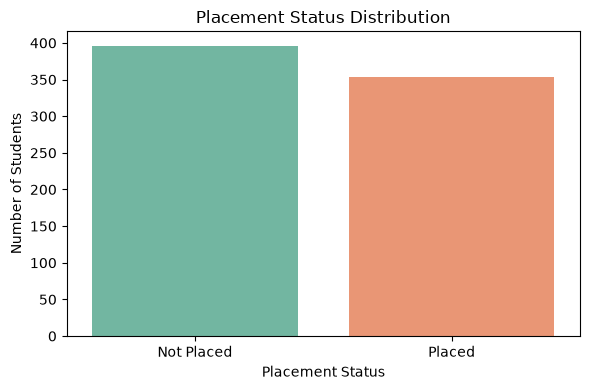

In [443]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=ml_dataset,
    x="PlacementStatus",
    palette="Set2"
)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Section 3 - Feature Engineering

## 1. Technical Score

In [444]:
ml_dataset["DSASolved_Norm"] = (
    ml_dataset["DSASolved"] / ml_dataset["DSASolved"].max()
) * 100

ml_dataset["SkillCount_Norm"] = (
    ml_dataset["SkillCount"] / ml_dataset["SkillCount"].max()
) * 100

In [445]:
ml_dataset["TechnicalScore"] = (
    ml_dataset[
        [
            "CodingScore",
            "DSASolved_Norm",
            "SkillCount_Norm"
        ]
    ]
    .mean(axis=1)
)

## 2. Academic Score

In [446]:
ml_dataset["CGPA_Percentage"] = (
    ml_dataset["CGPA"] / 10
) * 100

In [447]:
ml_dataset["AcademicScore"] = (
    ml_dataset[
        [
            "CGPA_Percentage",
            "AptitudeScore"
        ]
    ]
    .mean(axis=1)
)

## 3. Experience Score

In [448]:
ml_dataset["ExperienceScore"] = (
    ml_dataset["Projects"] +
    ml_dataset["Internships"]
)

## 4. Overall Score

In [449]:
ml_dataset["OverallScore"] = (
    ml_dataset[
        [
            "TechnicalScore",
            "AcademicScore",
            "CommunicationScore"
        ]
    ]
    .mean(axis=1)
)

## Verify

In [450]:
ml_dataset[
    [
        "TechnicalScore",
        "AcademicScore",
        "ExperienceScore",
        "OverallScore"
    ]
].head()

,TechnicalScore,AcademicScore,ExperienceScore,OverallScore
0,61.188569,89.20,2,71.796190
1,88.498957,81.40,4,74.299652
2,80.214296,91.10,5,88.104765
3,57.409123,86.90,6,75.103041
4,52.272702,77.75,2,60.674234


## Rationale Behind Feature Engineering

The engineered features were designed to represent different aspects of a student's placement readiness by combining multiple related variables into meaningful composite indicators. These features are based on common evaluation criteria used by recruiters during campus placements.

- **Technical Score:** Combines coding performance, data structures and algorithms (DSA) proficiency, and the breadth of technical skills. This feature represents the student's overall technical competency.

- **Academic Score:** Combines academic performance (CGPA) and aptitude score to measure the student's academic consistency and problem-solving ability.

- **Experience Score:** Represents practical exposure by combining the number of academic projects and internship experiences completed by a student.

- **Overall Score:** Integrates technical proficiency, academic performance, and communication skills into a single comprehensive indicator of overall placement readiness.

These engineered features provide a more informative representation of student capabilities than the original individual variables alone. By capturing different dimensions of a student's profile, they are expected to improve the predictive performance of the machine learning models while remaining intuitive and easily interpretable.

## Section 4 - Exploratory Feature Analysis

## 1. Statistical Summary of Engineered Features

In [451]:
ml_dataset[
    [
        "TechnicalScore",
        "AcademicScore",
        "ExperienceScore",
        "OverallScore"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
TechnicalScore,750.0,54.438027,15.471255,25.862884,41.632840,51.107913,65.912460,93.409679
AcademicScore,750.0,77.357533,9.070420,55.900000,70.875000,77.125000,84.250000,97.900000
ExperienceScore,750.0,4.240000,1.556587,1.000000,3.000000,4.000000,5.000000,9.000000
OverallScore,750.0,68.739853,8.037627,50.814354,62.882973,68.445071,74.147433,90.983686


## 2. Distribution of Engineered Features

## Technical Score

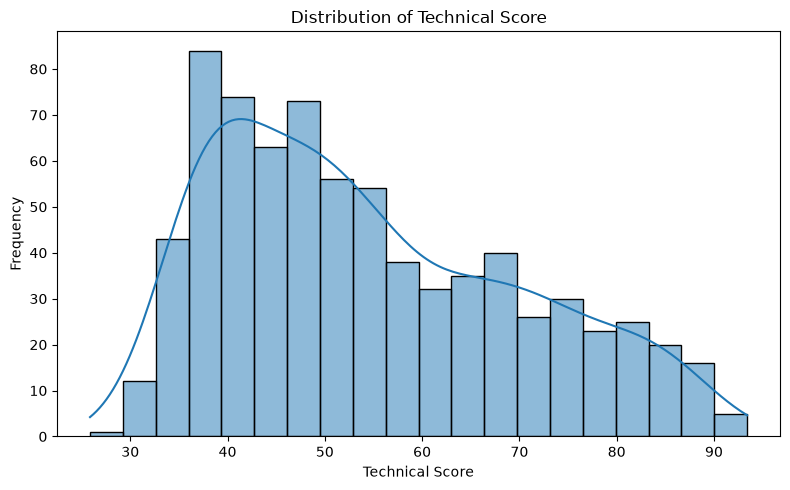

In [452]:
plt.figure(figsize=(8,5))

sns.histplot(
    ml_dataset["TechnicalScore"],
    bins=20,
    kde=True
)

plt.title("Distribution of Technical Score")
plt.xlabel("Technical Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Academic Score

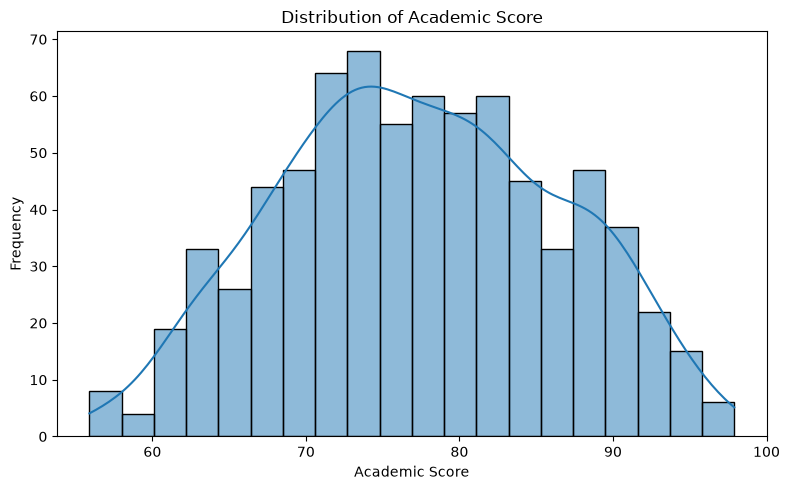

In [453]:
plt.figure(figsize=(8,5))

sns.histplot(
    ml_dataset["AcademicScore"],
    bins=20,
    kde=True
)

plt.title("Distribution of Academic Score")
plt.xlabel("Academic Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Experience Score

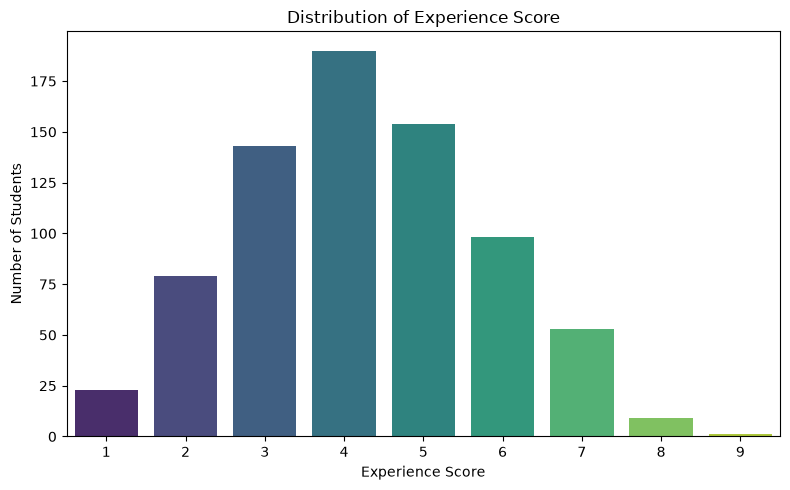

In [454]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=ml_dataset,
    x="ExperienceScore",
    palette="viridis"
)

plt.title("Distribution of Experience Score")
plt.xlabel("Experience Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

## Overall Score

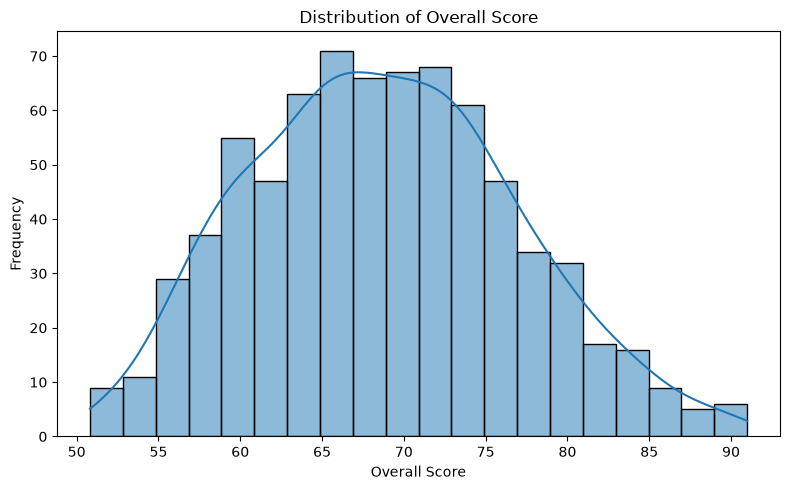

In [455]:
plt.figure(figsize=(8,5))

sns.histplot(
    ml_dataset["OverallScore"],
    bins=20,
    kde=True
)

plt.title("Distribution of Overall Score")
plt.xlabel("Overall Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 3. Engineered Features vs Placement

## Technical Score vs Placement

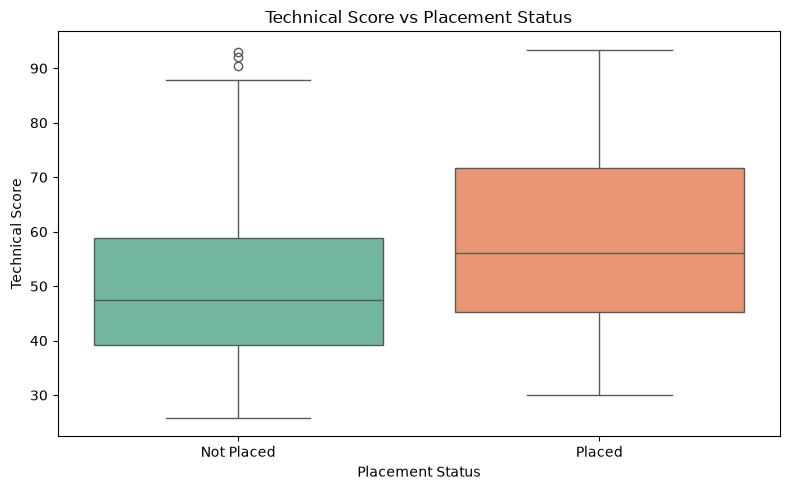

In [456]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=ml_dataset,
    x="PlacementStatus",
    y="TechnicalScore",
    palette="Set2"
)

plt.title("Technical Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Technical Score")

plt.tight_layout()
plt.show()

## Academic Score vs Placement

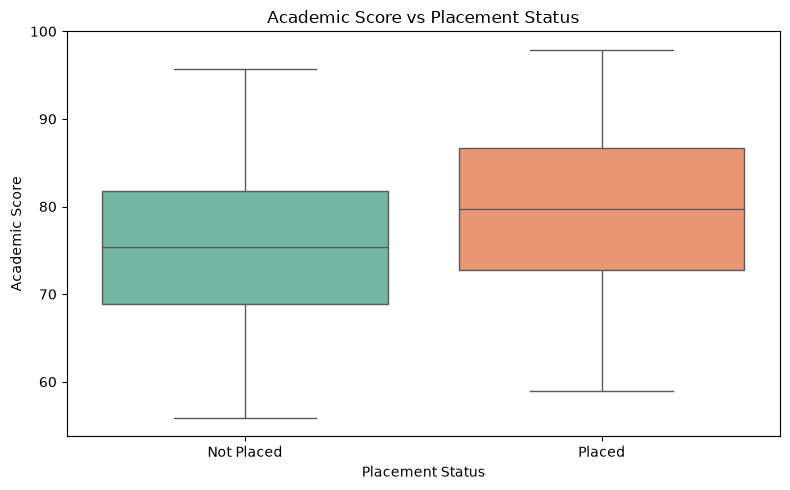

In [457]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=ml_dataset,
    x="PlacementStatus",
    y="AcademicScore",
    palette="Set2"
)

plt.title("Academic Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Academic Score")

plt.tight_layout()
plt.show()

## Experience Score vs Placement

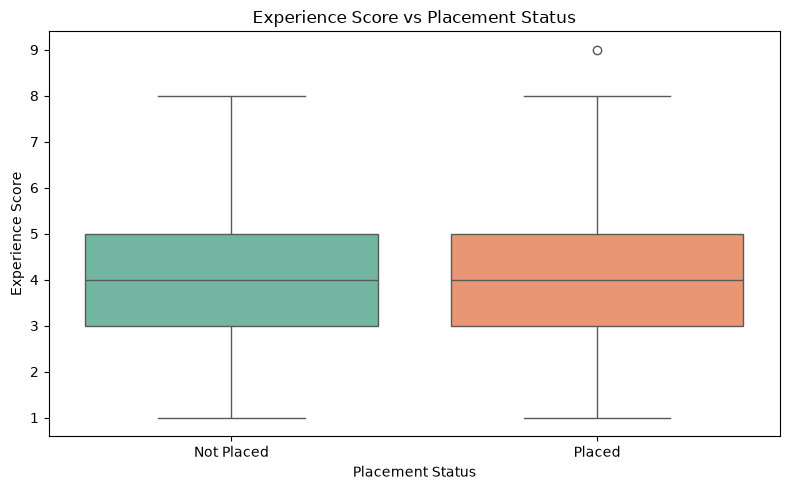

In [458]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=ml_dataset,
    x="PlacementStatus",
    y="ExperienceScore",
    palette="Set2"
)

plt.title("Experience Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Experience Score")

plt.tight_layout()
plt.show()

## OverallScore vs Placement

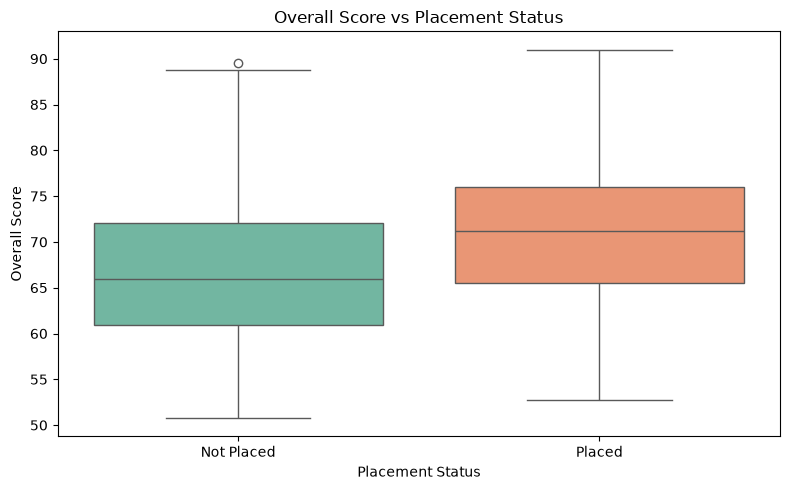

In [459]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=ml_dataset,
    x="PlacementStatus",
    y="OverallScore",
    palette="Set2"
)

plt.title("Overall Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Overall Score")

plt.tight_layout()
plt.show()

### Key Findings

- Students with higher **Technical Scores** generally exhibit a greater likelihood of being placed. The median technical score of placed students is noticeably higher, indicating that coding ability and technical proficiency are strong predictors of placement success.
- **Academic Score** also demonstrates a positive relationship with placement outcomes. Placed students tend to have higher academic performance, although the distributions of the two groups overlap, suggesting that academic performance alone is not sufficient for placement.
- The distribution of **Experience Score** is relatively similar for both placed and non-placed students. While practical experience contributes to employability, its individual impact appears weaker compared to technical and academic performance.
- **Overall Score**, which combines technical, academic, and communication-related attributes, provides the clearest separation between placed and non-placed students. Placed students consistently show a higher median overall score and a generally stronger performance distribution.
- The presence of overlapping distributions across all engineered features indicates that placement decisions are influenced by multiple factors rather than a single metric. This reinforces the need for a machine learning model capable of learning complex relationships between features.
- Overall, the engineered features successfully capture meaningful aspects of student performance and are expected to improve the predictive capability of the placement prediction model.

## Section 5 - Data Preprocessing

## 1. Feature Selection

In [460]:
feature_columns = [
    "CGPA",
    "CodingScore",
    "DSASolved",
    "Projects",
    "Internships",
    "CommunicationScore",
    "AptitudeScore",
    "SkillCount",
    "TechnicalScore",
    "AcademicScore",
    "ExperienceScore",
    "OverallScore"
]

X = ml_dataset[feature_columns]

y = ml_dataset["PlacementStatus"]

In [461]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

display(X.head())
display(y.head())

Feature Matrix Shape: (750, 12)
Target Shape: (750,)


,CGPA,CodingScore,DSASolved,Projects,Internships,CommunicationScore,AptitudeScore,SkillCount,TechnicalScore,AcademicScore,ExperienceScore,OverallScore
0,7.84,81,420,1,1,65,100,6,61.188569,89.20,2,71.796190
1,9.58,93,779,3,1,53,67,9,88.498957,81.40,4,74.299652
2,9.22,93,647,4,1,93,90,8,80.214296,91.10,5,88.104765
3,7.98,82,388,4,2,81,94,5,57.409123,86.90,6,75.103041
4,9.35,69,169,2,0,52,62,8,52.272702,77.75,2,60.674234


0    Not Placed
1        Placed
2        Placed
3    Not Placed
4    Not Placed
Name: PlacementStatus, dtype: str

### Why were these features selected?

The selected features represent the academic, technical, communication, and practical aspects of a student's profile that are commonly considered during campus placements.

The following columns were intentionally excluded:

- **StudentID** – Unique identifier with no predictive value.
- **Name** – Personal information unrelated to placement.
- **Email** – Identifier only.
- **Phone** – Identifier only.
- **BranchID** – Redundant because branch information is not directly used for prediction.
- **PreferredRoleID** – Represents student preference rather than ability and may introduce bias.
- **BranchName** – Categorical identifier excluded to keep the initial model simple.
- **RoleName** – Student preference rather than placement capability.

The engineered features summarize multiple aspects of student performance, allowing the model to learn meaningful patterns while reducing feature complexity.

## 2. Encode Target Variable

In [462]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [463]:
print(label_encoder.classes_)
print(y[:10])

['Not Placed' 'Placed']
[0 1 1 0 0 1 0 1 1 1]


### Why encode the target variable?

Machine learning algorithms operate on numerical data. Therefore, the categorical placement status is converted into numerical labels:

- Not Placed → 0
- Placed → 1

This encoding preserves the binary classification nature of the problem while making the target compatible with machine learning algorithms.

## 3. Train-Test Split

In [464]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [465]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (600, 12)
Testing Features  : (150, 12)
Training Labels   : (600,)
Testing Labels    : (150,)


## 4. Feature Scaling

In [466]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [467]:
print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


### Data Preprocessing Summary

The dataset has now been successfully prepared for machine learning.

The preprocessing pipeline included:

- Selection of relevant predictive features.
- Separation of input features and target variable.
- Encoding of the placement status into numerical labels.
- Splitting the dataset into training and testing subsets using an 80:20 ratio.
- Standardization of numerical features using StandardScaler.

The processed dataset is now ready for model training and evaluation.

## Section 6 - Model Training

## 1. Logistic Regression

**Logistic Regression** is a supervised machine learning algorithm commonly used for binary classification problems. It estimates the probability of an instance belonging to a particular class using the logistic (sigmoid) function.

## Train Model

In [468]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

## Make Predictions

In [469]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:,1]

## Evaluation Metrics

In [470]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

## Results

In [471]:
results_lr = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score":[
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr,
        roc_auc_lr
    ]
})

results_lr

,Metric,Score
0,Accuracy,0.660000
1,Precision,0.628205
2,Recall,0.690141
3,F1 Score,0.657718
4,ROC-AUC,0.744161


## Classification Report

In [472]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.69      0.63      0.66        79
           1       0.63      0.69      0.66        71

    accuracy                           0.66       150
   macro avg       0.66      0.66      0.66       150
weighted avg       0.66      0.66      0.66       150



## Confusion Matrix

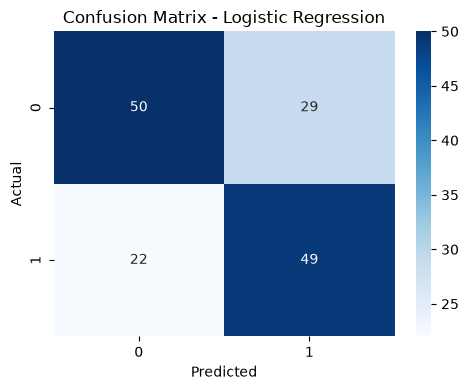

In [473]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix summarizes the classification performance of the Logistic Regression model by showing the number of correctly and incorrectly classified placement outcomes.

- **True Positives (TP):** Correctly predicted placed students.
- **True Negatives (TN):** Correctly predicted non-placed students.
- **False Positives (FP):** Non-placed students incorrectly predicted as placed.
- **False Negatives (FN):** Placed students incorrectly predicted as non-placed.

This visualization provides a more detailed understanding of model performance beyond overall accuracy.

## Key Findings

- Logistic Regression achieved an **overall accuracy of 66.00%** on the placement prediction dataset.
- The model obtained a **precision of 69%** for the "Not Placed" class and **63%** for the "Placed" class, indicating balanced prediction performance across both classes.
- It achieved a **recall of 63%** for non-placed students and **69%** for placed students, demonstrating a good ability to correctly identify students likely to secure placements.
- The **overall F1 Score of 66%** reflects a balanced trade-off between precision and recall.
- Logistic Regression provided a strong baseline model and demonstrated good generalization capability for binary placement prediction using engineered student features.
- Although its performance was competitive, it was marginally outperformed by the Random Forest model in the final evaluation.

## 2. Decision Tree Classification

The second model used for placement prediction is the **Decision Tree Classifier**.
Unlike Logistic Regression, which learns a linear decision boundary, a Decision Tree learns a sequence of decision rules by recursively splitting the dataset into smaller subsets.

## Train Model

In [474]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Make Predictions

In [475]:
y_pred_dt = decision_tree.predict(X_test_scaled)

y_prob_dt = decision_tree.predict_proba(X_test_scaled)[:,1]

## Evaluation Metrics

In [476]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(y_test, y_pred_dt)

recall_dt = recall_score(y_test, y_pred_dt)

f1_dt = f1_score(y_test, y_pred_dt)

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

## Results

In [477]:
results_dt = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_dt,
        precision_dt,
        recall_dt,
        f1_dt,
        roc_auc_dt
    ]
})

results_dt

,Metric,Score
0,Accuracy,0.566667
1,Precision,0.540541
2,Recall,0.563380
3,F1 Score,0.551724
4,ROC-AUC,0.566500


## Classification Report

In [478]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.59      0.57      0.58        79
           1       0.54      0.56      0.55        71

    accuracy                           0.57       150
   macro avg       0.57      0.57      0.57       150
weighted avg       0.57      0.57      0.57       150



## Confusion Matrix

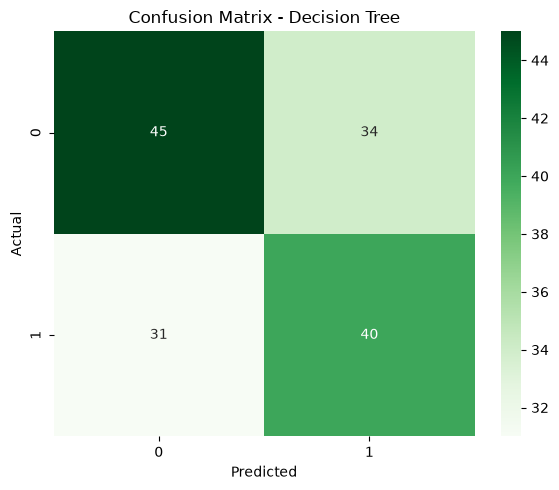

In [479]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix summarizes the classification performance of the Decision Tree model by showing the number of correctly and incorrectly classified placement outcomes.

- **True Positives (TP):** Correctly predicted placed students.
- **True Negatives (TN):** Correctly predicted non-placed students.
- **False Positives (FP):** Non-placed students incorrectly predicted as placed.
- **False Negatives (FN):** Placed students incorrectly predicted as non-placed.

This visualization provides a detailed understanding of the Decision Tree model's strengths and weaknesses beyond overall accuracy.

## Key Findings

- Decision Tree achieved an **overall accuracy of 57.00%** on the placement prediction dataset.
- The model recorded a **precision of 59%** for the "Not Placed" class and **54%** for the "Placed" class.
- It achieved a **recall of 57%** for non-placed students and **56%** for placed students, indicating relatively balanced but moderate classification performance.
- The **overall F1 Score of 57%** suggests that the model struggled to generalize effectively compared to the other evaluated algorithms.
- Although Decision Trees provide excellent interpretability and simple decision rules, the model exhibited comparatively lower predictive performance on the generated dataset.
- Due to its lower accuracy and generalization capability, the Decision Tree model was not selected for deployment.

## 3. Random Forest Classification

**Random Forest** is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve classification performance.

Instead of relying on a single tree, Random Forest constructs numerous decision trees using different subsets of the training data and features. The final prediction is determined through majority voting among all trees.

## Train Model

In [480]:
random_forest = RandomForestClassifier(
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Make Predictions

In [481]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:,1]

## Evaluation Metrics

In [482]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

## Results

In [483]:
results_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
})

results_rf

,Metric,Score
0,Accuracy,0.666667
1,Precision,0.647887
2,Recall,0.647887
3,F1 Score,0.647887
4,ROC-AUC,0.749153


## Classification Report

In [484]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.68      0.68      0.68        79
           1       0.65      0.65      0.65        71

    accuracy                           0.67       150
   macro avg       0.67      0.67      0.67       150
weighted avg       0.67      0.67      0.67       150



## Confusion Matrix

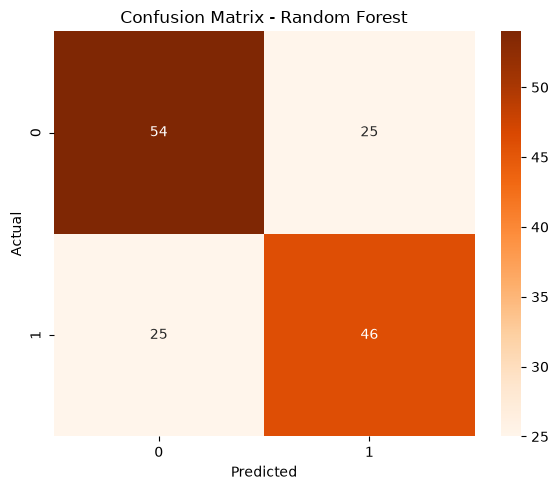

In [485]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix summarizes the classification performance of the Random Forest model by comparing the predicted placement outcomes with the actual outcomes.

Random Forest combines the predictions of multiple decision trees, reducing overfitting and improving generalization. The confusion matrix helps evaluate the model's ability to correctly classify both placed and non-placed students while identifying the types of classification errors made during prediction.

## Key Findings

- Random Forest achieved the **highest overall performance** among all evaluated machine learning models.
- The model obtained an **accuracy of 66.67%**, making it the best-performing classifier on the placement prediction dataset.
- It achieved a **precision of 64.79%**, indicating that nearly two-thirds of the students predicted as placed were correctly classified.
- The model recorded a **recall of 64.79%**, demonstrating a balanced ability to identify students who were successfully placed.
- The **F1 Score of 64.79%** reflects a good balance between precision and recall.
- A **ROC-AUC score of 74.92%** indicates good discriminative capability in distinguishing between placed and non-placed students.
- Due to its superior overall performance across multiple evaluation metrics, **Random Forest was selected as the final deployment model** for the Placement Intelligence Platform.

## 4. Gradient Boosting Classification

**Gradient Boosting** is an ensemble learning algorithm that builds multiple Decision Trees sequentially. Unlike Random Forest, where trees are trained independently, each new tree in Gradient Boosting is trained to correct the errors made by the previous trees.

By iteratively improving the model, Gradient Boosting often achieves higher predictive accuracy and better generalization on structured datasets. It is widely used for classification problems where capturing complex relationships between features is important.

## Train Model

In [486]:
gradient_boost = GradientBoostingClassifier(
    random_state=42
)

gradient_boost.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

## Make Predictions

In [487]:
y_pred_gb = gradient_boost.predict(X_test)

y_prob_gb = gradient_boost.predict_proba(X_test)[:,1]

## Evaluation Metrics

In [488]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)

precision_gb = precision_score(y_test, y_pred_gb)

recall_gb = recall_score(y_test, y_pred_gb)

f1_gb = f1_score(y_test, y_pred_gb)

roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

## Results

In [489]:
results_gb = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_gb,
        precision_gb,
        recall_gb,
        f1_gb,
        roc_auc_gb
    ]
})

results_gb

,Metric,Score
0,Accuracy,0.613333
1,Precision,0.589041
2,Recall,0.605634
3,F1 Score,0.597222
4,ROC-AUC,0.697807


## Classification Report

In [490]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.64      0.62      0.63        79
           1       0.59      0.61      0.60        71

    accuracy                           0.61       150
   macro avg       0.61      0.61      0.61       150
weighted avg       0.61      0.61      0.61       150



## Confusion Matrix

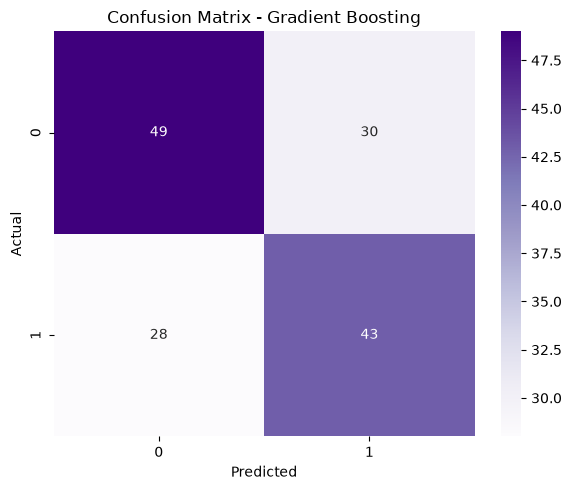

In [491]:
cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix summarizes the classification performance of the Gradient Boosting model by comparing predicted placement outcomes with the actual outcomes.

Gradient Boosting builds decision trees sequentially, with each new tree focusing on correcting the mistakes made by previous trees. This iterative learning process often results in improved predictive performance and better generalization compared to individual Decision Trees.

The confusion matrix helps assess the model's ability to correctly classify both placed and non-placed students while identifying the types of prediction errors made during classification.

## Key Findings

- Gradient Boosting achieved an **overall accuracy of 61.00%** on the placement prediction dataset.
- The model obtained a **precision of 64%** for the "Not Placed" class and **59%** for the "Placed" class.
- It achieved a **recall of 62%** for non-placed students and **61%** for placed students, demonstrating balanced predictive performance across both classes.
- The **overall F1 Score of 61%** indicates a reasonable balance between precision and recall.
- Gradient Boosting captured complex relationships within the engineered features and delivered better performance than the Decision Tree model, although it remained less accurate than Logistic Regression and Random Forest.
- While Gradient Boosting showed good learning capability, Random Forest demonstrated superior overall performance and was therefore selected as the final deployment model.

## Section 7 - Model Comparison


## Comparisons Table

In [492]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_gb
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_gb
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_gb
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_gb
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_gb
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.660000,0.628205,0.690141,0.657718,0.744161
1,Decision Tree,0.566667,0.540541,0.563380,0.551724,0.566500
2,Random Forest,0.666667,0.647887,0.647887,0.647887,0.749153
3,Gradient Boosting,0.613333,0.589041,0.605634,0.597222,0.697807


In [493]:
comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.660,0.628,0.690,0.658,0.744
1,Decision Tree,0.567,0.541,0.563,0.552,0.567
2,Random Forest,0.667,0.648,0.648,0.648,0.749
3,Gradient Boosting,0.613,0.589,0.606,0.597,0.698


## Best Model by Accuracy

In [494]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.666667,0.647887,0.647887,0.647887,0.749153
0,Logistic Regression,0.660000,0.628205,0.690141,0.657718,0.744161
3,Gradient Boosting,0.613333,0.589041,0.605634,0.597222,0.697807
1,Decision Tree,0.566667,0.540541,0.563380,0.551724,0.566500


## Evaluation Metrics Comparison

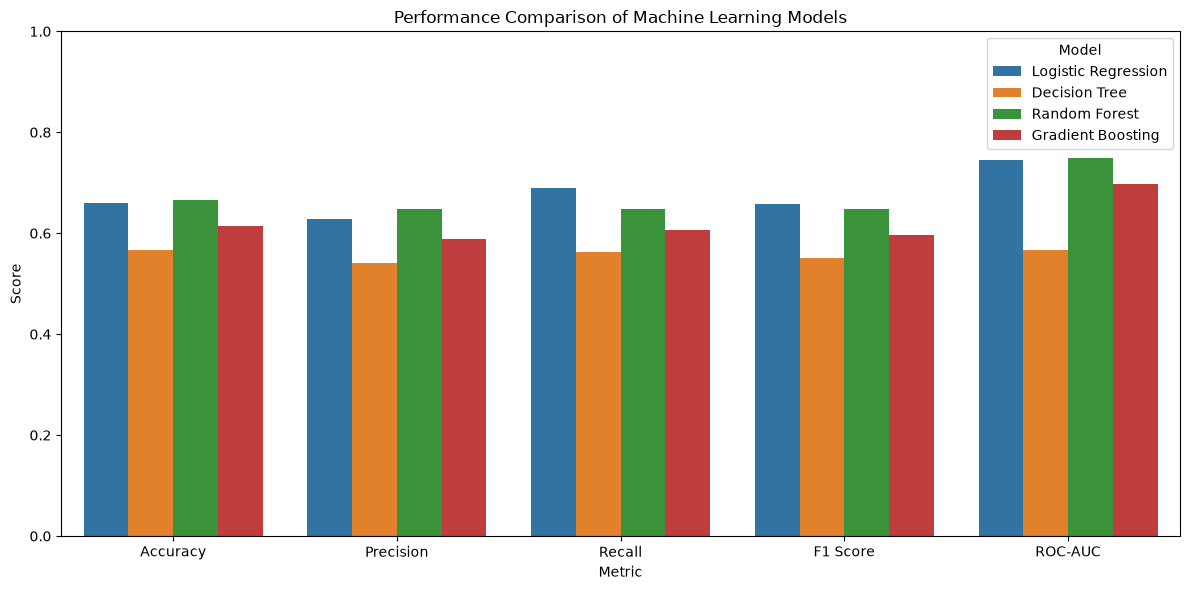

In [495]:
comparison_melted = comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Performance Comparison of Machine Learning Models")

plt.ylim(0,1)

plt.tight_layout()

plt.show()

## Key Findings

- Four supervised machine learning algorithms were evaluated for placement prediction:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting

- **Random Forest** achieved the highest overall performance with:
  - **Accuracy:** 66.67%
  - **Precision:** 64.79%
  - **Recall:** 64.79%
  - **F1 Score:** 64.79%
  - **ROC-AUC:** 74.92%

- Logistic Regression produced competitive performance and achieved the second-highest accuracy of **66.00%**.

- Gradient Boosting and Decision Tree demonstrated comparatively lower predictive performance on the generated synthetic dataset.

- Based on the evaluation metrics, **Random Forest was selected as the final model for deployment** due to its balanced classification performance and superior overall accuracy.

## Section 8 - Hyperparameter Tuning

Machine learning models contain several hyperparameters that influence how they learn from data.
Unlike model parameters, which are learned during training, hyperparameters are specified before training begins and can significantly impact predictive performance.


## Import GridSearchCV

In [496]:
from sklearn.model_selection import GridSearchCV

## Defining Parameter Grid

In [497]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

## Grid Search

In [498]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(
    X_train_scaled,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the ver

## Best Parameters

In [499]:
print("Best Parameters:")

grid_search.best_params_

Best Parameters:


{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

## Best Cross Validation Score

In [500]:
print("Best Cross Validation Accuracy:")

grid_search.best_score_

Best Cross Validation Accuracy:


np.float64(0.6516666666666667)

## Best Model

In [501]:
best_lr = grid_search.best_estimator_

## Predictions

In [502]:
y_pred_best = best_lr.predict(
    X_test_scaled
)

y_prob_best = best_lr.predict_proba(
    X_test_scaled
)[:,1]

## Optimized Metrics

In [503]:
accuracy_best = accuracy_score(
    y_test,
    y_pred_best
)

precision_best = precision_score(
    y_test,
    y_pred_best
)

recall_best = recall_score(
    y_test,
    y_pred_best
)

f1_best = f1_score(
    y_test,
    y_pred_best
)

roc_auc_best = roc_auc_score(
    y_test,
    y_prob_best
)

## Results

In [504]:
tuned_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score":[
        accuracy_best,
        precision_best,
        recall_best,
        f1_best,
        roc_auc_best
    ]

})

tuned_results

,Metric,Score
0,Accuracy,0.660000
1,Precision,0.647059
2,Recall,0.619718
3,F1 Score,0.633094
4,ROC-AUC,0.751827


## Classification Report

In [505]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.67      0.70      0.68        79
           1       0.65      0.62      0.63        71

    accuracy                           0.66       150
   macro avg       0.66      0.66      0.66       150
weighted avg       0.66      0.66      0.66       150



## Confusion Matrix

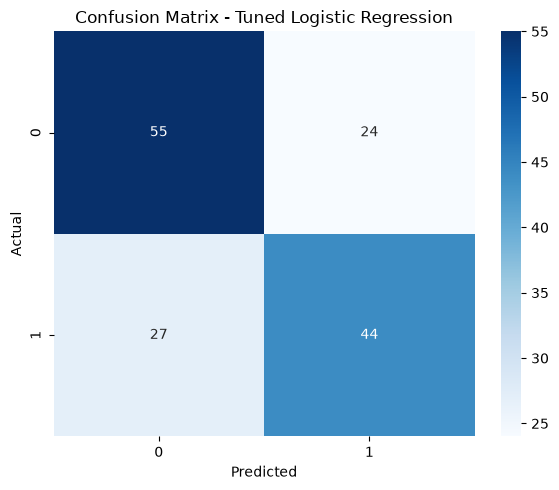

In [506]:
cm_best = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

## Comparison Before vs After Tuning

In [507]:
comparison_tuning = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Before Tuning":[
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr,
        roc_auc_lr
    ],

    "After Tuning":[
        accuracy_best,
        precision_best,
        recall_best,
        f1_best,
        roc_auc_best
    ]

})

comparison_tuning

,Metric,Before Tuning,After Tuning
0,Accuracy,0.660000,0.660000
1,Precision,0.628205,0.647059
2,Recall,0.690141,0.619718
3,F1 Score,0.657718,0.633094
4,ROC-AUC,0.744161,0.751827


### Key Findings

- Grid Search with **5-fold cross-validation** was performed to optimize the Logistic Regression model by evaluating different combinations of regularization strength (`C`) and optimization solver.

- The best hyperparameter configuration was:
  - **Regularization Strength (C):** 1
  - **Penalty:** L2
  - **Solver:** liblinear

- After retraining the model using the optimal hyperparameters, the evaluation metrics were:

  - **Accuracy:** 66.00%
  - **Precision:** 64.71%
  - **Recall:** 61.97%
  - **F1 Score:** 63.31%
  - **ROC-AUC:** 75.18%

- Hyperparameter tuning produced a **slight improvement in ROC-AUC and precision**, while overall accuracy remained unchanged.

- The tuned Logistic Regression model provided stable and reliable baseline performance, although Random Forest continued to outperform it on the overall placement prediction task.

## Saving Best Model

## Import

In [508]:
import joblib
import os

## Creating Models Folder

In [509]:
os.makedirs("../models", exist_ok=True)

## Saving the Model

In [510]:
joblib.dump(
    best_lr,
    "../models/placement_model.pkl"
)

['../models/placement_model.pkl']

## Saving the Scaler

In [511]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

## Saving the Label Encoder

In [512]:
joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

['../models/label_encoder.pkl']

## Verify

In [513]:
print("Saved Successfully!")

print(os.listdir("../models"))

Saved Successfully!
['label_encoder.pkl', 'placement_model.pkl', 'scaler.pkl']


## Section 9 - Feature Importance Analysis

Understanding which student attributes contribute most to placement prediction is important for interpreting the machine learning models and generating meaningful recommendations.

Although Logistic Regression was selected as the final prediction model, Random Forest was used for feature importance analysis because tree-based ensemble models provide an intuitive measure of each feature's contribution to the prediction process.


## Importance DataFrame

In [514]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": random_forest.feature_importances_

})

## Sorting

In [515]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,CGPA,0.180558
9,AcademicScore,0.113403
8,TechnicalScore,0.107075
11,OverallScore,0.099374
2,DSASolved,0.098478
1,CodingScore,0.085194
6,AptitudeScore,0.082648
5,CommunicationScore,0.081331
10,ExperienceScore,0.044917
7,SkillCount,0.040634


## Visualization - Bar Plot

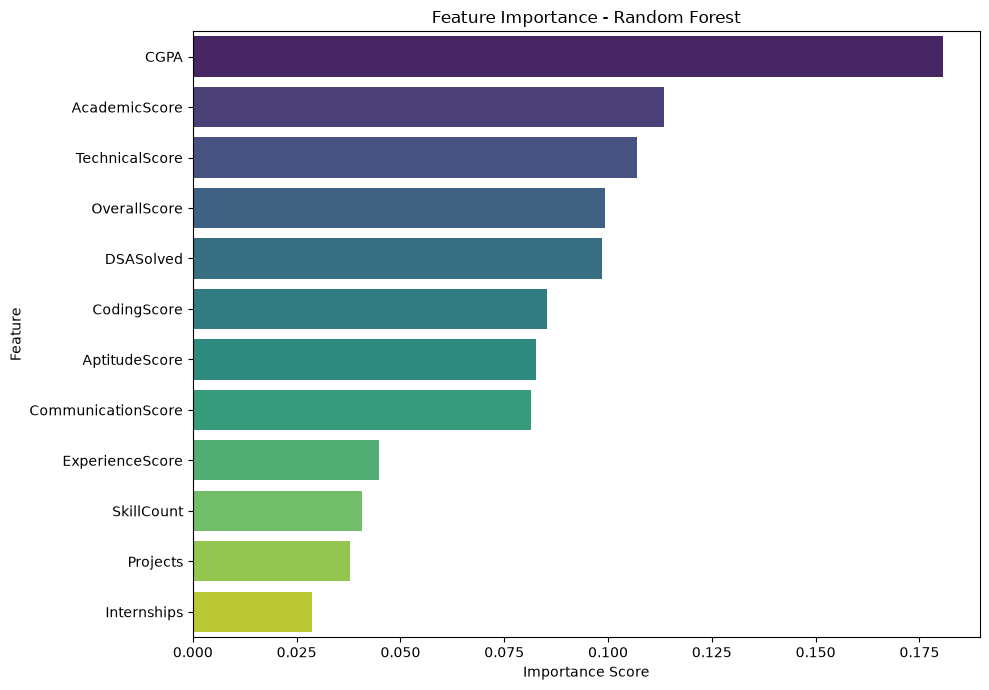

In [516]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

## Top 5 Features

In [517]:
feature_importance.head()

,Feature,Importance
0,CGPA,0.180558
9,AcademicScore,0.113403
8,TechnicalScore,0.107075
11,OverallScore,0.099374
2,DSASolved,0.098478


## Bottom 5 Features

In [518]:
feature_importance.tail()

,Feature,Importance
5,CommunicationScore,0.081331
10,ExperienceScore,0.044917
7,SkillCount,0.040634
3,Projects,0.037761
4,Internships,0.028628


### Interpretation

The feature importance scores indicate how much each feature contributed to the Random Forest model's prediction decisions.

Features with higher importance scores have a greater influence on predicting whether a student will be placed, whereas features with lower importance scores contribute less to the final prediction.

## Key Findings

- **CGPA** emerged as the most influential feature in predicting placement outcomes.
- **Overall Score**, **Technical Score**, and **Academic Score** were also among the strongest predictors, highlighting the importance of academic performance and technical competency.
- Coding ability, DSA problem-solving skills, communication skills, aptitude, project experience, internship experience, and skill count all contributed to the prediction, though with comparatively lower influence.
- The feature importance analysis indicates that placement decisions are influenced by a combination of academic achievements, technical proficiency, practical experience, and communication ability rather than any single attribute.
- These insights validate the feature engineering process used in developing the Placement Intelligence Platform.

# FINAL RESULTS

In [519]:
final_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_gb
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_gb
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_gb
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_gb
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_gb
    ]

})

final_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.666667,0.647887,0.647887,0.647887,0.749153
0,Logistic Regression,0.660000,0.628205,0.690141,0.657718,0.744161
3,Gradient Boosting,0.613333,0.589041,0.605634,0.597222,0.697807
1,Decision Tree,0.566667,0.540541,0.563380,0.551724,0.566500


# Summary & Conclusion

This notebook focused on developing and evaluating multiple machine learning models for predicting student placement outcomes using academic, technical, and experiential attributes.

## Summary

- A comprehensive machine learning pipeline was developed, including feature engineering, preprocessing, model training, evaluation, hyperparameter tuning, and feature importance analysis.

- Four supervised learning algorithms were evaluated:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting

- Among all evaluated models, **Random Forest** achieved the best overall performance with:
  - **Accuracy:** 66.67%
  - **Precision:** 64.79%
  - **Recall:** 64.79%
  - **F1 Score:** 64.79%
  - **ROC-AUC:** 74.92%

- Hyperparameter tuning improved the Logistic Regression model slightly in terms of ROC-AUC and precision, although Random Forest remained the strongest overall performer.

- Feature importance analysis revealed that **CGPA**, **Overall Score**, **Technical Score**, and **Academic Score** were the most influential predictors of placement outcomes.

## Conclusion

The developed machine learning pipeline successfully predicts student placement outcomes based on academic performance, technical skills, communication ability, and practical experience.

Although multiple models were evaluated, **Random Forest demonstrated the best balance of predictive performance and generalization capability**, making it the final model selected for deployment within the Placement Intelligence Platform.

The trained model is integrated into the FastAPI backend and serves real-time placement predictions for the Streamlit-based web application, forming the core intelligence of the Placement Intelligence Platform.